In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.patches as mpatches

In [2]:
# import pandas as pd

# df1= pd.read_csv("data/final/fd_df_gc.csv")
# df2= pd.read_csv("data/final/sd_df_gc.csv")


# df=pd.merge(df1, df2, on=["PID"])
# df.columns = df.columns.str.replace('_x$', '', regex=True)
# df.columns = df.columns.str.replace('_y$', '', regex=True)
# df = df.loc[:, ~df.columns.duplicated()]

# df.drop(columns=['Shannon Diversity', "Simpson's Index"], inplace=True)
# df.to_csv("data/final/combined_df_gc.csv", index=False)

In [12]:
import os 

pwd = os.getcwd()
print(pwd)

/home/qli/Projects/FD_Stability


In [13]:
comb_fi_df=pd.read_csv("results/feature_importance_results_combined.csv") 

comb_models_df=pd.read_csv("results/model_results_combined.csv")

func_df = comb_fi_df[comb_fi_df["Feature"] == "Functional Diversity"]


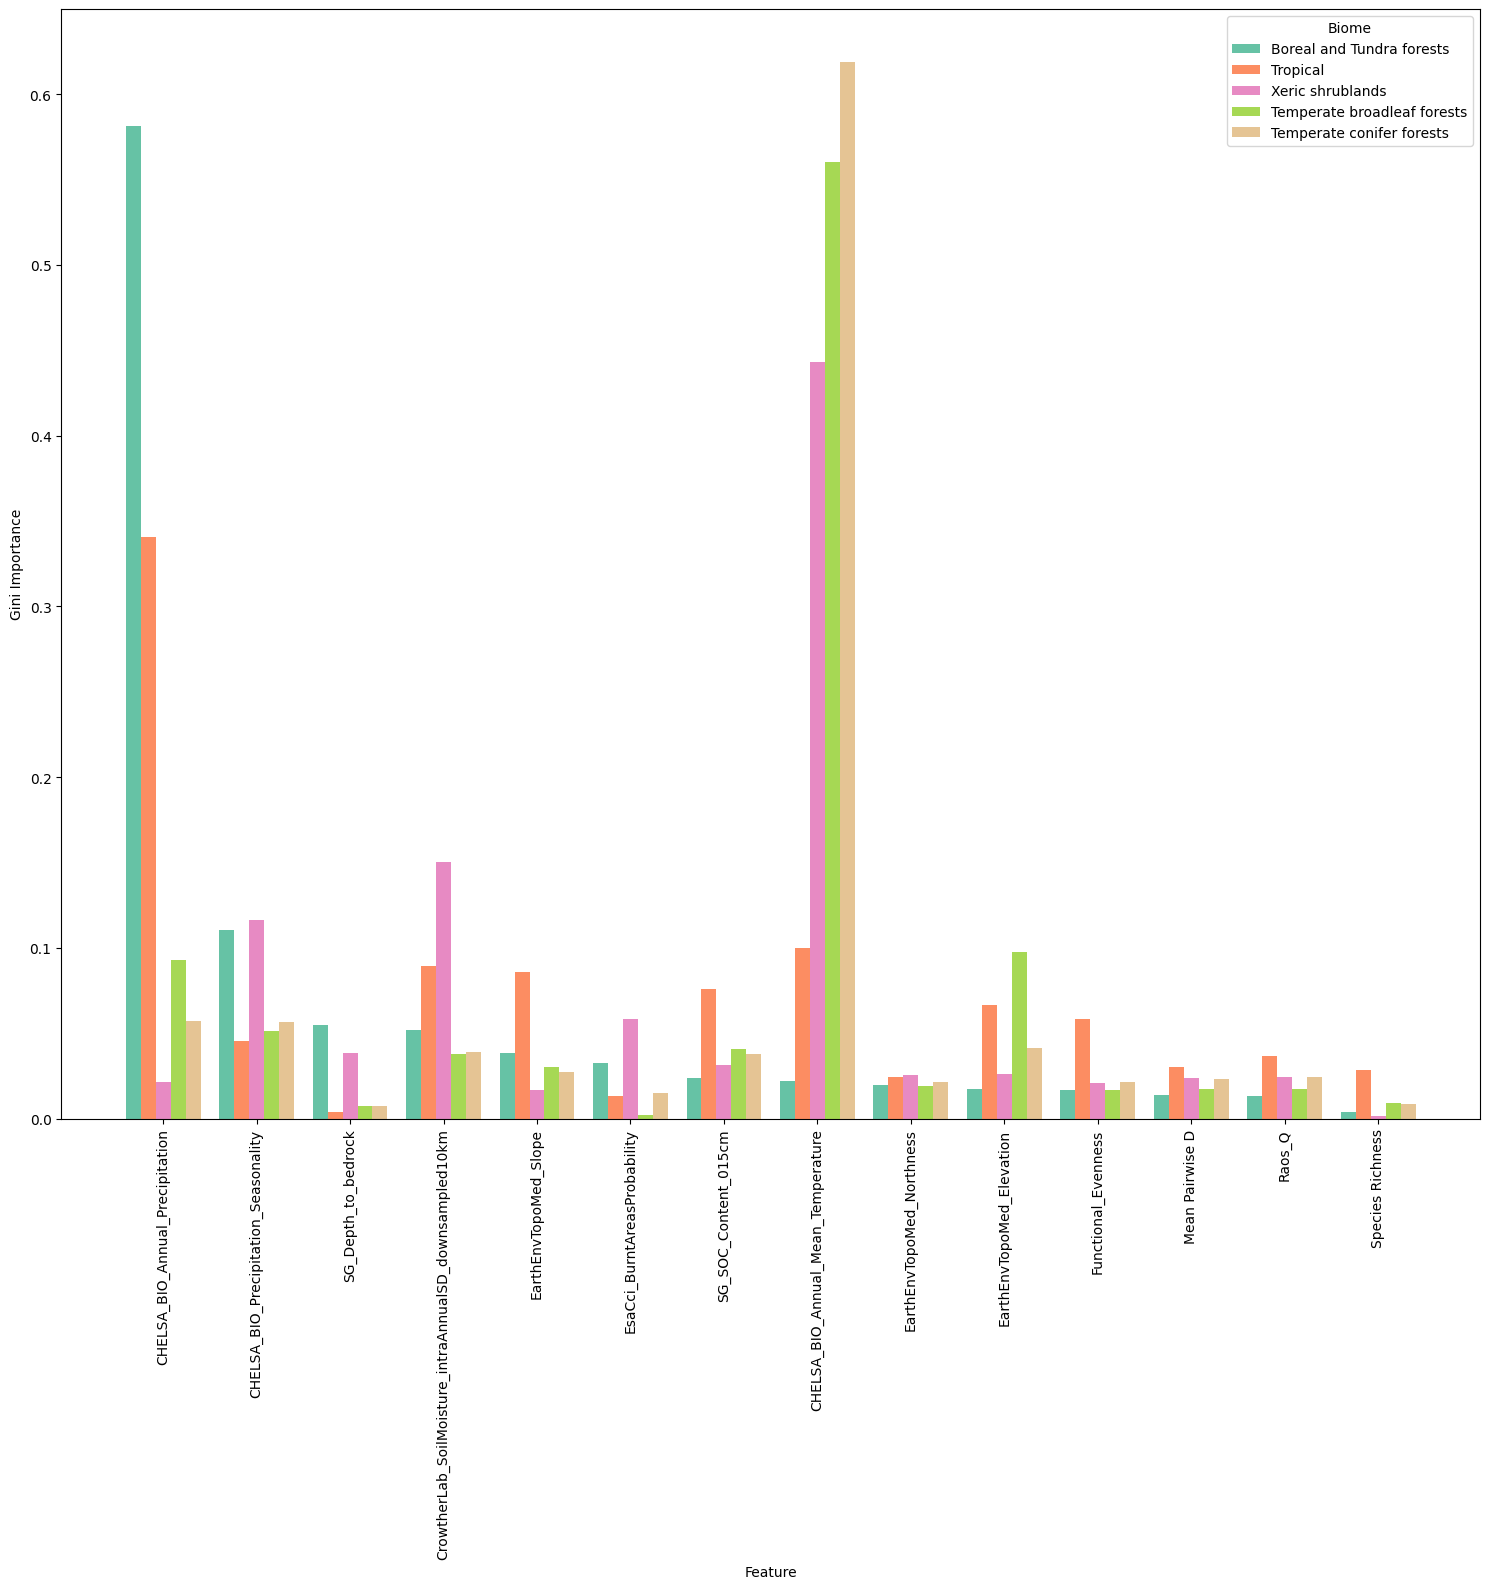

In [14]:
feature = comb_fi_df["Feature"].unique()
biomes = comb_fi_df["biome"].unique()

x = np.arange(len(feature))
width = 0.8 / len(biomes)

cmap = plt.cm.Set2
biome_colors = {b: cmap(i / len(biomes)) for i, b in enumerate(biomes)}

fig, ax = plt.subplots(figsize=(15, 16))

for i, biome in enumerate(biomes):
    sub = comb_fi_df[comb_fi_df["biome"] == biome]
    
    # align values to ownership order
    y = [sub[sub["Feature"] == o]["Gini Importance"].values[0] if o in sub["Feature"].values else 0
         for o in feature]

    ax.bar(
        x + i * width,
        y,
        width=width,
        label=biome,
        color=biome_colors[biome]
    )

ax.set_xticks(x + width * (len(biomes)-1) / 2)
ax.set_xticklabels(feature, rotation=90)
ax.set_xlabel("Feature")
ax.set_ylabel("Gini Importance")
ax.legend(title="Biome")

plt.tight_layout()
plt.show()

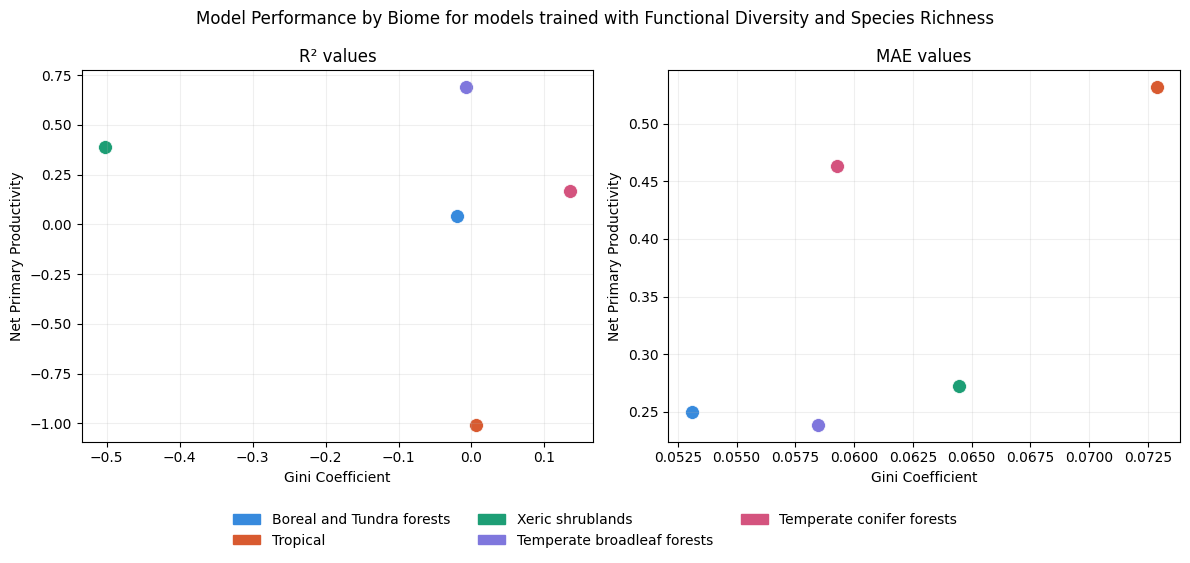

In [10]:
biome_colors = {
    'Boreal and Tundra forests':    '#378ADD',
    'Tropical':                     '#D85A30',
    'Xeric shrublands':             '#1D9E75',
    'Temperate broadleaf forests':  '#7F77DD',
    'Temperate conifer forests':    '#D4537E',
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Model Performance by Biome for models trained with Functional Diversity and Species Richness', fontsize=12)

for ax, metric, title in zip(axes, ['r2', 'mae'], ['R² values', 'MAE values']):
    subset = comb_models_df[comb_models_df['metric'] == metric]
    for _, row in subset.iterrows():
        ax.scatter(row['gc'], row['npp'], color=biome_colors[row['biome']], s=100, edgecolors='white', linewidths=0.5)
    ax.set_xlabel('Gini Coefficient')
    ax.set_ylabel('Net Primary Productivity')
    ax.set_title(title)
    ax.grid(True, alpha=0.2)

legend_handles = [mpatches.Patch(color=c, label=b) for b, c in biome_colors.items()]
fig.legend(handles=legend_handles, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.12), frameon=False)
plt.tight_layout()
plt.show()

In [15]:
fi_df=pd.read_csv("results/feature_importance_results_fd.csv") 
fis_df=pd.read_csv("results/feature_importance_results_sd.csv")

sd_models_df=pd.read_csv("results/model_results_sd.csv")
fd_models_df=pd.read_csv("results/model_results_fd.csv")

func_df = fi_df[fi_df["Feature"] == "Functional Diversity"]
spec_df= fis_df[fis_df["Feature"] == "Species Diversity"]

diversity_df=pd.concat([func_df, spec_df], ignore_index=True)


In [ ]:
f_list = ['Raos_Q', 'Functional_Evenness', "Mean Pairwise D"]
s_list = ['Species Richness', 'Shannon Diversity', "Simpson's Index"]

In [ ]:
func_df = fi_df[fi_df["Feature"].isin(f_list)]
spec_df= fis_df[fis_df["Feature"].isin(s_list)]

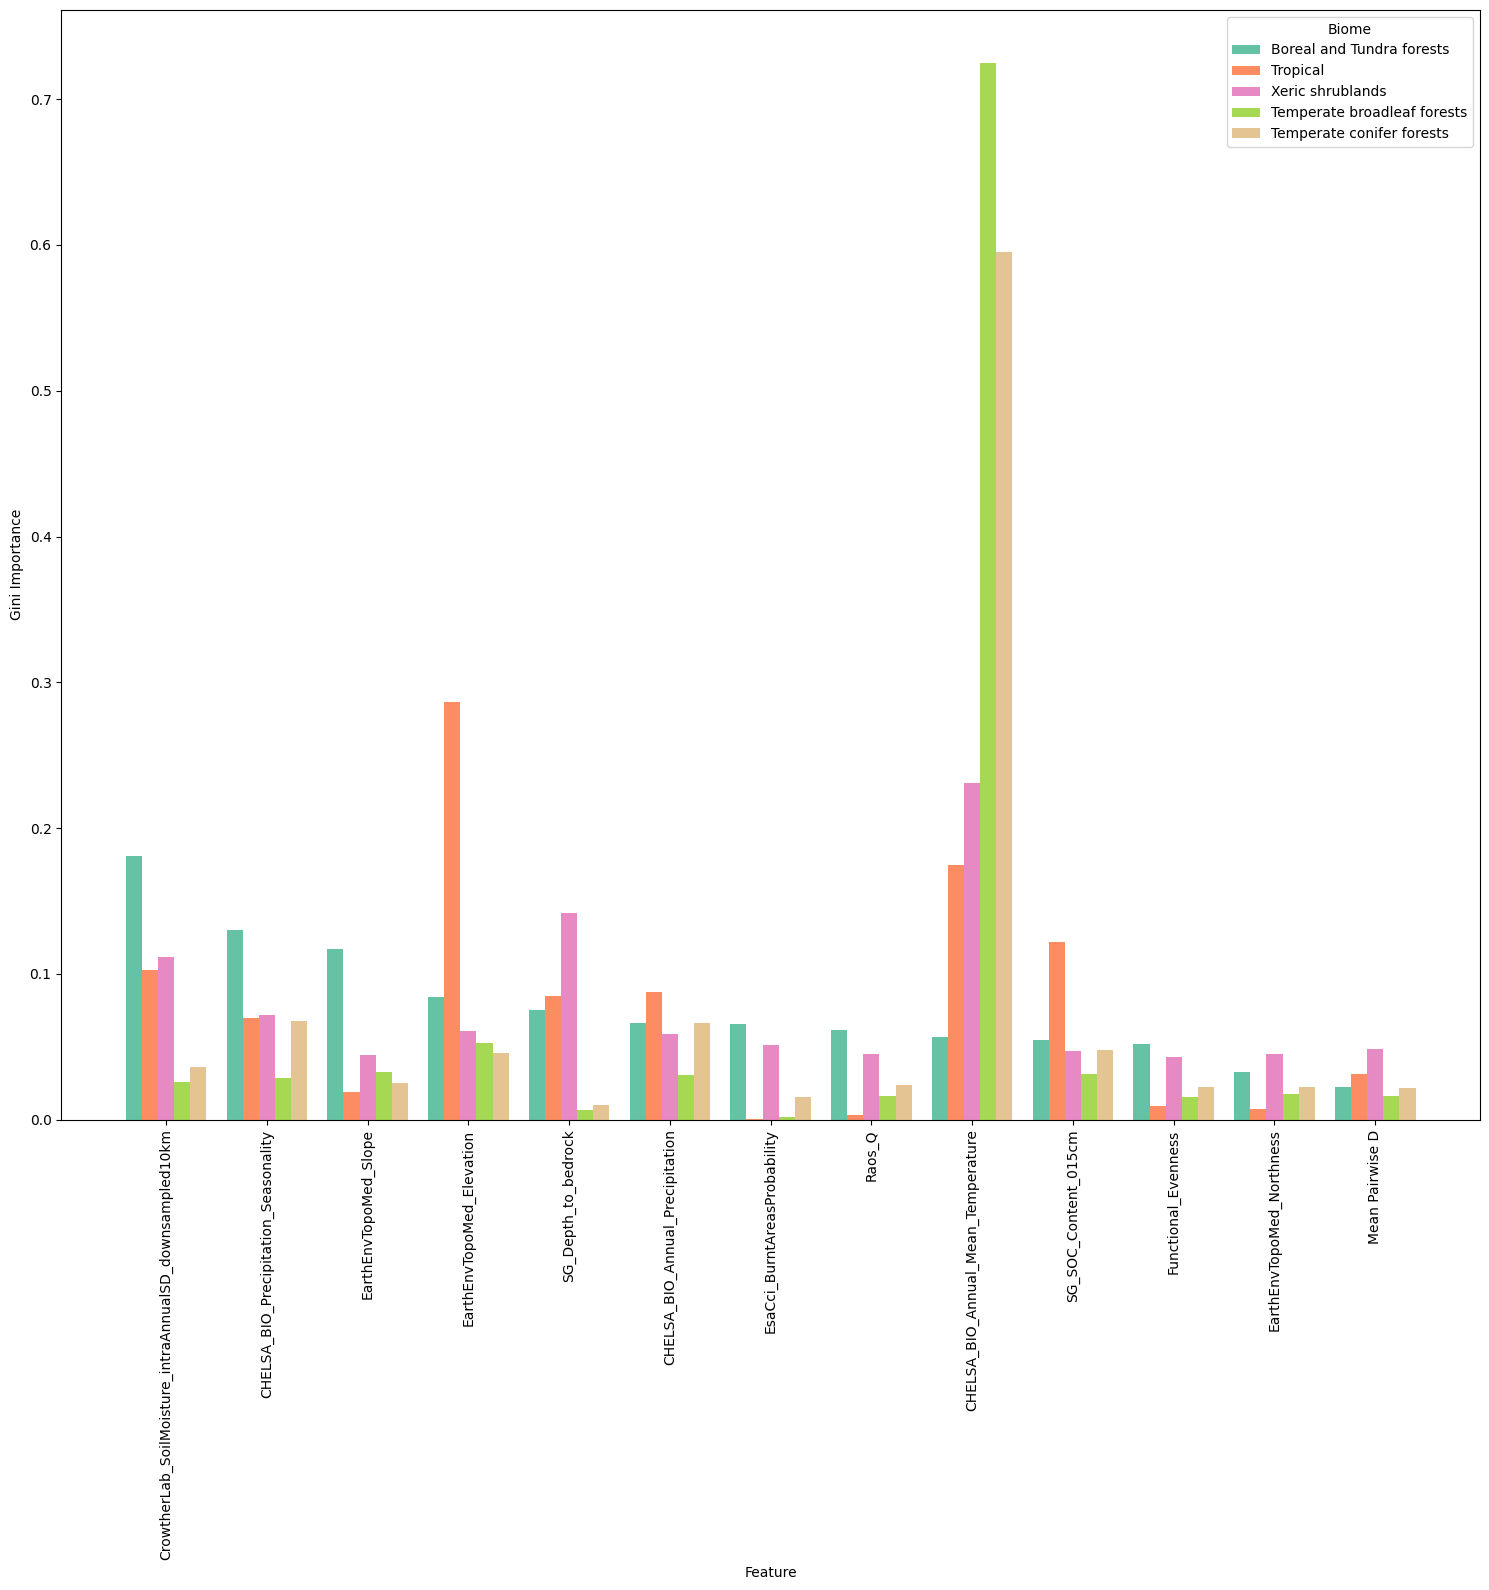

In [16]:

feature = fi_df["Feature"].unique()
biomes = fi_df["biome"].unique()

x = np.arange(len(feature))
width = 0.8 / len(biomes)

cmap = plt.cm.Set2
biome_colors = {b: cmap(i / len(biomes)) for i, b in enumerate(biomes)}

fig, ax = plt.subplots(figsize=(15, 16))

for i, biome in enumerate(biomes):
    sub = fi_df[fi_df["biome"] == biome]
    
    # align values to ownership order
    y = [sub[sub["Feature"] == o]["Gini Importance"].values[0] if o in sub["Feature"].values else 0
         for o in feature]

    ax.bar(
        x + i * width,
        y,
        width=width,
        label=biome,
        color=biome_colors[biome]
    )

ax.set_xticks(x + width * (len(biomes)-1) / 2)
ax.set_xticklabels(feature, rotation=90)
ax.set_xlabel("Feature")
ax.set_ylabel("Gini Importance")
ax.legend(title="Biome")

plt.tight_layout()
plt.show()

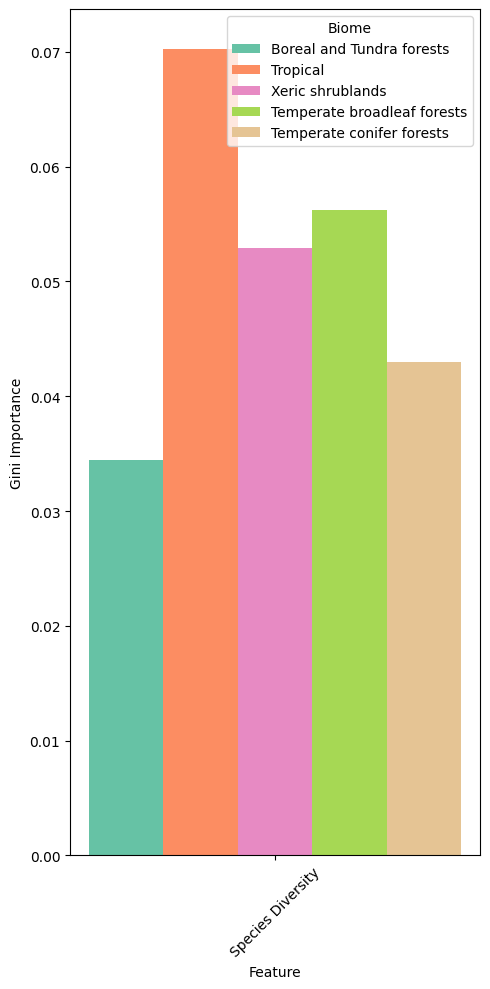

In [17]:
feature = diversity_df["Feature"].unique()
biomes = diversity_df["biome"].unique()

x = np.arange(len(feature))
width = 0.8 / len(biomes)

cmap = plt.cm.Set2
biome_colors = {b: cmap(i / len(biomes)) for i, b in enumerate(biomes)}

fig, ax = plt.subplots(figsize=(5, 10))


for i, biome in enumerate(biomes):
    sub = diversity_df[diversity_df["biome"] == biome]
    
    # align values to ownership order
    y = [sub[sub["Feature"] == o]["Gini Importance"].values[0] if o in sub["Feature"].values else 0
         for o in feature]

    ax.bar(
        x + i * width,
        y,
        width=width,
        label=biome,
        color=biome_colors[biome]
    )

ax.set_xticks(x + width * (len(biomes)-1) / 2)
ax.set_xticklabels(feature, rotation=45)
ax.set_xlabel("Feature")
ax.set_ylabel("Gini Importance")
ax.legend(title="Biome")

plt.tight_layout()
plt.show()

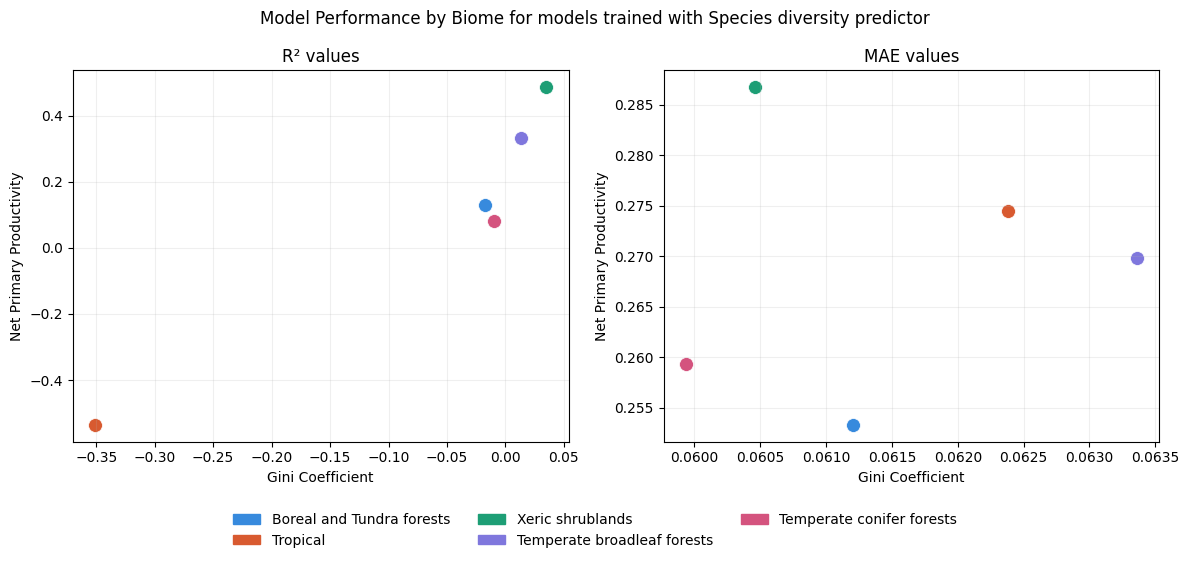

In [9]:
biome_colors = {
    'Boreal and Tundra forests':    '#378ADD',
    'Tropical':                     '#D85A30',
    'Xeric shrublands':             '#1D9E75',
    'Temperate broadleaf forests':  '#7F77DD',
    'Temperate conifer forests':    '#D4537E',
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Model Performance by Biome for models trained with Species diversity predictor', fontsize=12)

for ax, metric, title in zip(axes, ['r2', 'mae'], ['R² values', 'MAE values']):
    subset = sd_models_df[sd_models_df['metric'] == metric]
    for _, row in subset.iterrows():
        ax.scatter(row['gc'], row['npp'], color=biome_colors[row['biome']], s=100, edgecolors='white', linewidths=0.5)
    ax.set_xlabel('Gini Coefficient')
    ax.set_ylabel('Net Primary Productivity')
    ax.set_title(title)
    ax.grid(True, alpha=0.2)

legend_handles = [mpatches.Patch(color=c, label=b) for b, c in biome_colors.items()]
fig.legend(handles=legend_handles, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.12), frameon=False)
plt.tight_layout()
plt.show()